In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Logistic Regression model
from sklearn.linear_model import LogisticRegression

# Split dataset into training and testing sets
from sklearn.model_selection import train_test_split

# Feature scaling (Standardization)
from sklearn.preprocessing import StandardScaler

# Classification evaluation metrics
from sklearn.metrics import classification_report, confusion_matrix


In [2]:

df = pd.read_csv('Dataset/Cardiovascular_Disease.csv')
df.head()

# Display the first 5 rows

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [3]:
data=df[df.duplicated()]
data

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio


In [4]:
df['age']=df['age']//365



In [5]:
#height->150-200
#weight->45-120
#api_hi_>100-200
#ap_lo->50-90

In [6]:
data = df[
    (df['height'].between(150, 200)) &
    (df['weight'].between(45, 120)) &
    (df['ap_hi'].between(100, 200)) &
    (df['ap_lo'].between(50, 90))
]


<Axes: >

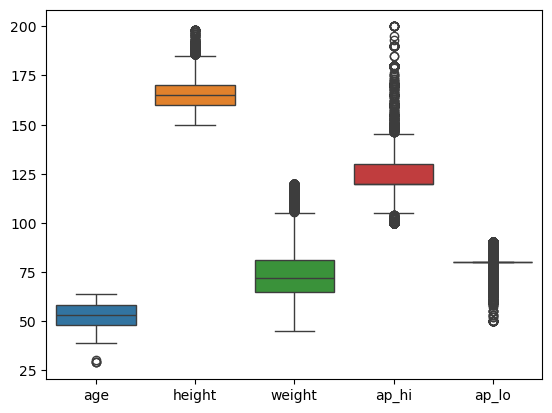

In [7]:


sns.boxplot(data[['age', 'height', 'weight', 'ap_hi', 'ap_lo']])

In [8]:
data

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,50,2,168,62.0,110,80,1,1,0,0,1,0
1,1,55,1,156,85.0,140,90,3,1,0,0,1,1
2,2,51,1,165,64.0,130,70,3,1,0,0,0,1
4,4,47,1,156,56.0,100,60,1,1,0,0,0,0
5,8,60,1,151,67.0,120,80,2,2,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69994,99992,57,1,165,80.0,150,80,1,1,0,0,1,1
69995,99993,52,2,168,76.0,120,80,1,1,1,0,1,0
69997,99996,52,2,183,105.0,180,90,3,1,0,1,0,1
69998,99998,61,1,163,72.0,135,80,1,2,0,0,0,1


In [9]:
# Remove the 'id' column
data = data.drop(columns='id')
data

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,50,2,168,62.0,110,80,1,1,0,0,1,0
1,55,1,156,85.0,140,90,3,1,0,0,1,1
2,51,1,165,64.0,130,70,3,1,0,0,0,1
4,47,1,156,56.0,100,60,1,1,0,0,0,0
5,60,1,151,67.0,120,80,2,2,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
69994,57,1,165,80.0,150,80,1,1,0,0,1,1
69995,52,2,168,76.0,120,80,1,1,1,0,1,0
69997,52,2,183,105.0,180,90,3,1,0,1,0,1
69998,61,1,163,72.0,135,80,1,2,0,0,0,1


In [10]:
# Select all rows where cardio = 0 (No cardiovascular disease)
data_0 = data[data['cardio'] == 0]

# Select all rows where cardio = 1 (Cardiovascular disease)
data_1 = data[data['cardio'] == 1]

In [11]:
data_0


,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,50,2,168,62.0,110,80,1,1,0,0,1,0
4,47,1,156,56.0,100,60,1,1,0,0,0,0
5,60,1,151,67.0,120,80,2,2,0,0,0,0
6,60,1,157,93.0,130,80,3,1,0,0,1,0
8,48,1,158,71.0,110,70,1,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
69987,51,1,151,49.0,120,80,1,1,0,0,1,0
69988,60,1,160,59.0,110,70,1,1,0,0,1,0
69991,56,1,159,72.0,130,90,2,2,0,0,1,0
69995,52,2,168,76.0,120,80,1,1,1,0,1,0


<Axes: >

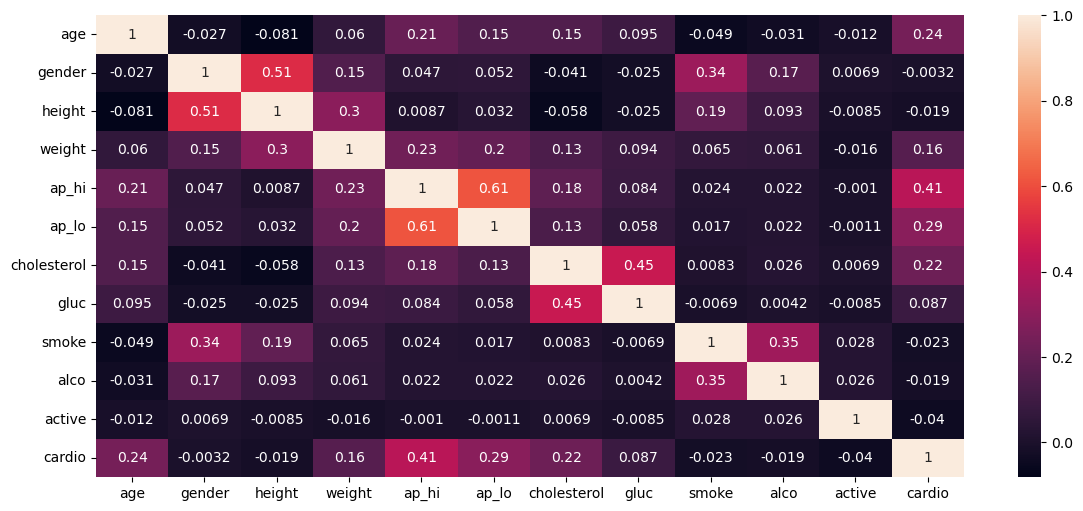

In [12]:
cor=data.corr()
plt.figure(figsize=(14,6))
sns.heatmap(cor,annot=True)

In [13]:
data.columns

Index(['age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol',
       'gluc', 'smoke', 'alco', 'active', 'cardio'],
      dtype='object')

In [14]:
feature=[ 'age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo',
       'cholesterol', 'gluc', 'smoke', 'alco', 'active']
target='cardio'

In [15]:
X=data[feature]
Y=data[target]

In [16]:
# Split the dataset into training and testing sets
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y,                 # Features (X) and target variable (Y)
    test_size=0.2,        # Use 20% of the data for testing and 80% for training
    random_state=42,      # Set a random seed for reproducible results
    stratify=Y            # Preserve the same class distribution in both training and testing sets
)

In [17]:
#(xi-mean)/sd

scaler = StandardScaler()


In [18]:
#fit_transform->feature training->fit(learning) transform(implement)
#transform(implementation)->features testing
X_train_scale = scaler.fit_transform(X_train)
X_test_scale = scaler.transform(X_test)

logistic regression model

In [19]:
# Create a Logistic Regression model with custom parameters
model = LogisticRegression(
    solver='liblinear',        # Optimization algorithm suitable for small datasets and binary classification
    class_weight='balanced',   # Automatically adjust class weights to handle imbalanced classes
    random_state=42            # Set a random seed for reproducible results
)

In [20]:
model.fit(X_train_scale,Y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'liblinear'
,max_iter,100
,multi_class,'deprecated'


In [21]:

# Testing / Prediction
# y = b0 + b1*x1 + b2*x2 + ... + bn*xn

Y_pred = model.predict(X_test_scale)

In [22]:
#Y_pred

metrics

In [23]:
# Generate the classification report (Precision, Recall, F1-score, and Accuracy)
cr = classification_report(Y_test, Y_pred)

# Generate the confusion matrix to compare actual vs predicted classes
cm = confusion_matrix(Y_test, Y_pred)


In [24]:
print(cr)

              precision    recall  f1-score   support

           0       0.72      0.76      0.74      6418
           1       0.71      0.67      0.69      5724

    accuracy                           0.72     12142
   macro avg       0.72      0.71      0.71     12142
weighted avg       0.72      0.72      0.72     12142



In [25]:
# Calculate Macro Average Precision
# Formula: (Precision of Class 0 + Precision of Class 1) / Number of Classes
#ma_p = (0.72 + 0.71) / 2
#print(ma_p)

# Calculate Macro Average Recall
# Formula: (Recall of Class 0 + Recall of Class 1) / Number of Classes
#ma_r = (0.76 + 0.67) / 2
#print(ma_r)


In [26]:
# Calculate Weighted Average Precision
# Formula: ((Precision_Class0 × Support_Class0) + (Precision_Class1 × Support_Class1)) / Total Support
#wa_p = ((0.72 * 6418) + (0.71 * 5724)) / 12142
#print(wa_p)

# Calculate Weighted Average Recall
# Formula: ((Recall_Class0 × Support_Class0) + (Recall_Class1 × Support_Class1)) / Total Support
#wa_r = ((0.76 * 6418) + (0.67 * 5724)) / 12142
#print(wa_r)   

<Axes: >

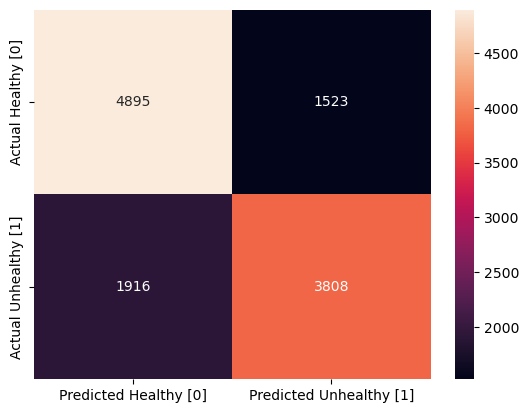

In [27]:
sns.heatmap(
    cm,
    annot=True,
    fmt='.0f',
    xticklabels=['Predicted Healthy [0]', 'Predicted Unhealthy [1]'],
    yticklabels=['Actual Healthy [0]', 'Actual Unhealthy [1]']
)           

In [28]:


# New patient data
data = {
    'age': [40, 30, 50],
    'gender': [1, 2, 1],
    'height': [160, 155, 170],
    'weight': [50, 60, 77],
    'ap_hi': [120, 170, 130],
    'ap_lo': [60, 80, 80],
    'cholesterol': [1, 1, 3],
    'gluc': [1, 1, 1],
    'smoke': [0, 1, 1],
    'alco': [1, 1, 0],
    'active': [1, 1, 0]
}

# Create a DataFrame
X_data = pd.DataFrame(data)

# Scale the data using the same scaler used during training
X_data_scale = scaler.transform(X_data)

# Predict cardiovascular disease
Y_new_pred = model.predict(X_data_scale)

# Add predictions to the DataFrame
X_data['predicted_cardio'] = Y_new_pred

# Display the results
print(X_data)

   age  gender  height  weight  ap_hi  ap_lo  cholesterol  gluc  smoke  alco  \
0   40       1     160      50    120     60            1     1      0     1   
1   30       2     155      60    170     80            1     1      1     1   
2   50       1     170      77    130     80            3     1      1     0   

   active  predicted_cardio  
0       1                 0  
1       1                 1  
2       0                 1  
